### Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the cleaned Dataset

In [3]:
df=pd.read_csv('../data/processed/retail_cleaned.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
 18  Year           9800

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Month_Name', 'Quarter',
       'Year_Month', 'Day', 'Day_of_Week', 'Shipping_Days'],
      dtype='str')

### Column Type
- Numerical - RowID, sales, year, month
- Categorical - ship mode, Segment, region, Category, month
- Mixed - Customer Name, Order ID, Customer ID

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month_Name,Quarter,Year_Month,Day,Day_of_Week,Shipping_Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,2017-11,8,Wednesday,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,2017-11,8,Wednesday,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,2017-06,12,Monday,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,2016-10,11,Tuesday,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,2016-10,11,Tuesday,7


### Basic business KPIs

In [7]:
total_sales=df['Sales'].sum()
total_sales

np.float64(2261536.7827)

In [8]:
total_orders=df['Order ID'].nunique()
total_orders

4922

In [9]:
total_customers=df['Customer ID'].nunique()
total_customers

793

In [10]:
total_orders=df['Product ID'].nunique()
total_orders

1861

In [11]:
average_order_value=total_sales/total_orders
average_order_value

np.float64(1215.2266430413756)

### Sales distribution

In [12]:
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

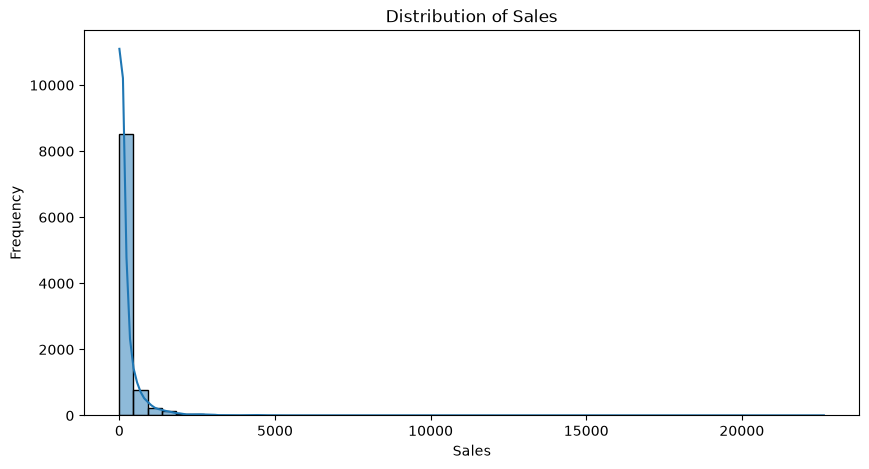

In [36]:
plt.figure(figsize=(10,5))
sns.histplot(df['Sales'],bins=50,kde=True)
plt.title("Distribution of Sales")
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

### Sales by year

In [14]:
yearly_sales=(df.groupby('Year')['Sales'].sum().reset_index())
yearly_sales

,Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


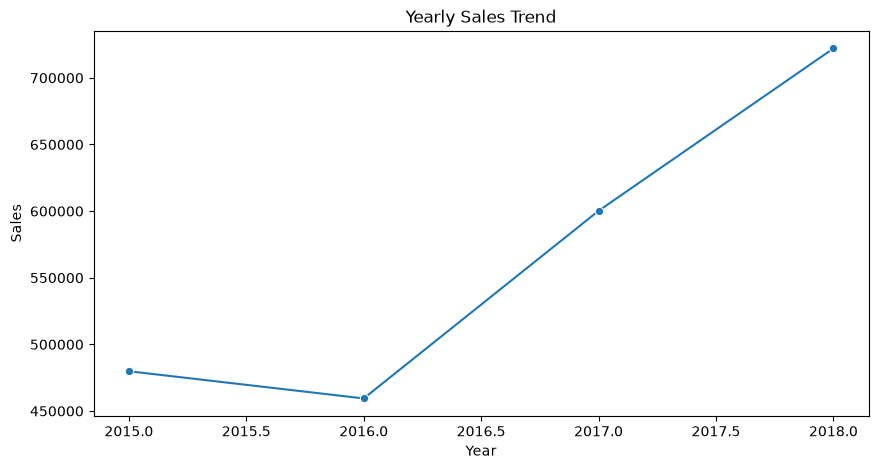

In [15]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_sales,x='Year',y='Sales',marker='o')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

### Monthly Sales

In [16]:
monthly_sales=(df.groupby('Month')['Sales'].sum().reset_index())
monthly_sales

,Month,Sales
0,1,94291.6296
1,2,59371.1154
2,3,197573.5872
3,4,136283.0006
4,5,154086.7237
5,6,145837.5233
6,7,145535.6890
7,8,157315.9270
8,9,300103.4117
9,10,199496.2947


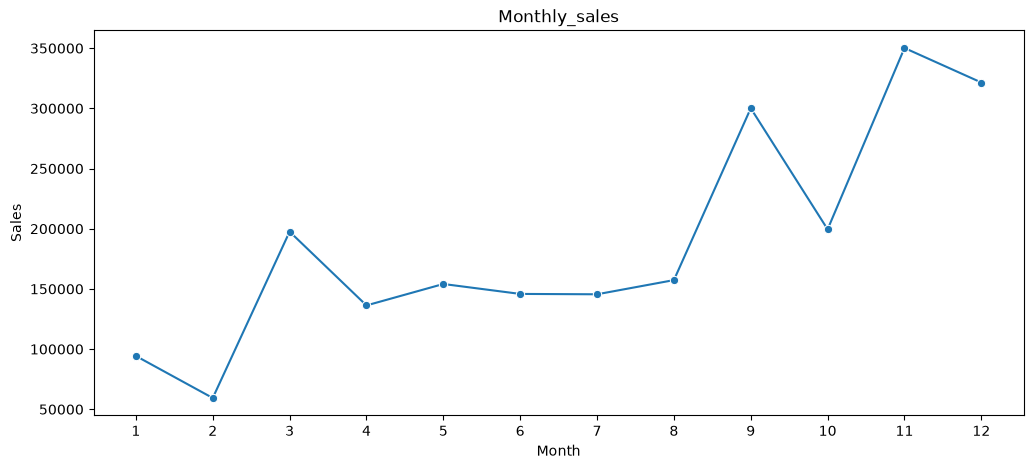

In [17]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales,x='Month',y='Sales',marker='o')
plt.title('Monthly_sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(range(1,13))
plt.show()

### Monthly Sales by year

In [38]:
monthly_yearly=(df.groupby(['Year','Month'])['Sales'].sum().reset_index())

monthly_yearly.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


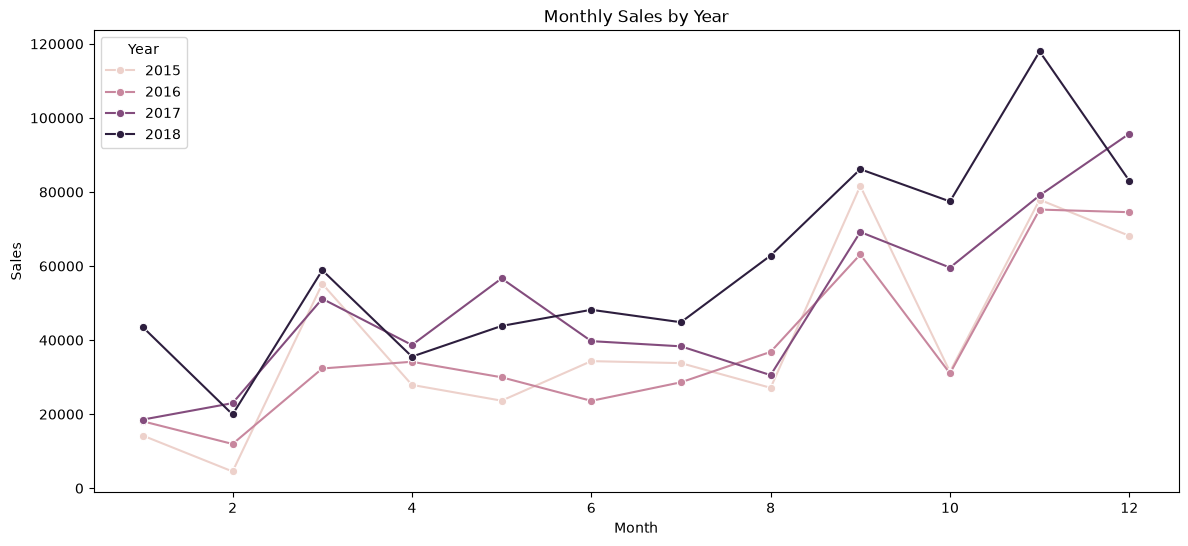

In [40]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_yearly,x='Month',y='Sales',hue='Year',marker='o')
plt.title('Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

### Quarterly analysis

In [20]:
quarterly_sales=(df.groupby('Quarter')['Sales'].sum().reset_index())
quarterly_sales

,Quarter,Sales
0,1,351236.3322
1,2,436207.2476
2,3,602955.0277
3,4,871138.1752


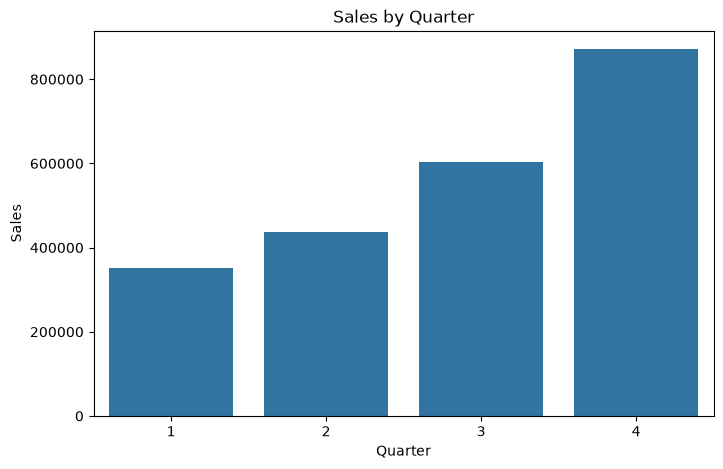

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(data=quarterly_sales,x='Quarter',y='Sales')
plt.title('Sales by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Sales')
plt.show()

### Sales by region

In [22]:
region_sales=(df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index())
region_sales

,Region,Sales
0,West,710219.6845
1,East,669518.7260
2,Central,492646.9132
3,South,389151.4590


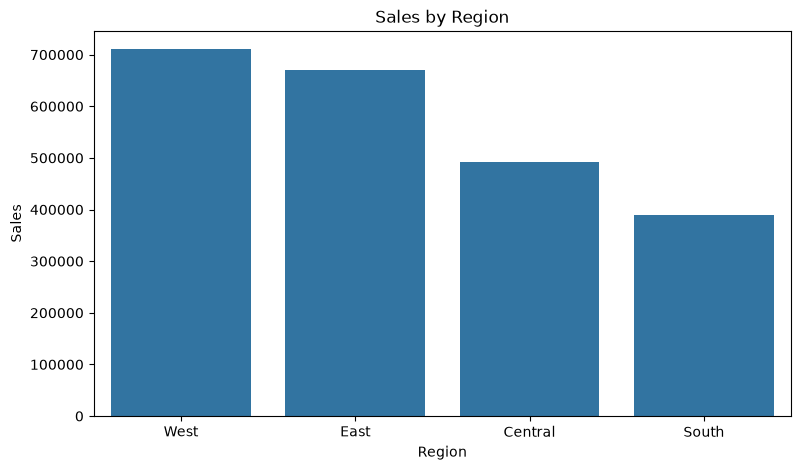

In [23]:
plt.figure(figsize=(9,5))
sns.barplot(data=region_sales,x='Region',y='Sales')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

### Sales by category

In [24]:
category_sales=(df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index())
category_sales

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


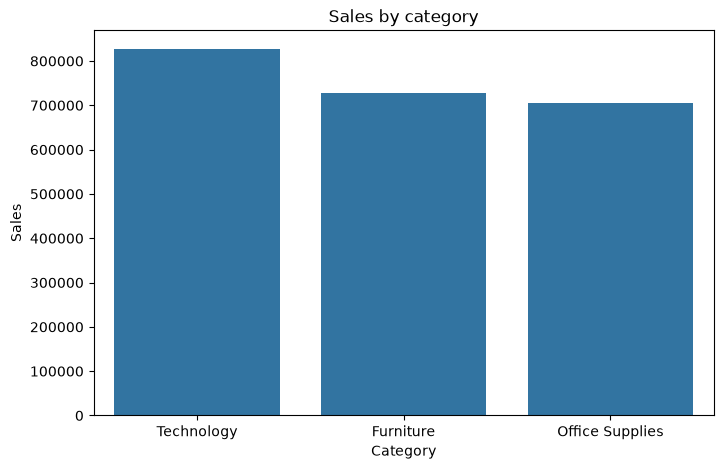

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=category_sales,x='Category',y='Sales')

plt.title('Sales by category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

### Sales by sub-category

In [26]:
subcategory_sales=(df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False))
subcategory_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

### Top 10 products

In [27]:
top_products=(df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10))
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

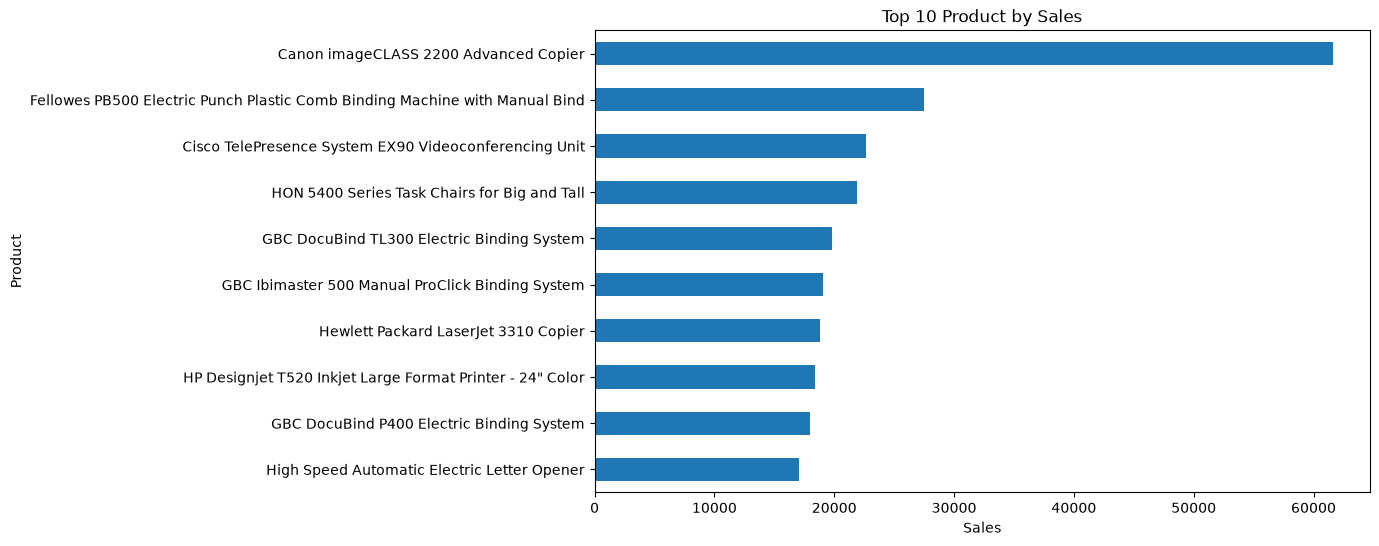

In [28]:
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Product by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

### Customer Segment Analysis

In [29]:
segment_sales=(df.groupby('Segment')['Sales'].sum().sort_values(ascending=False).reset_index())
segment_sales

,Segment,Sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


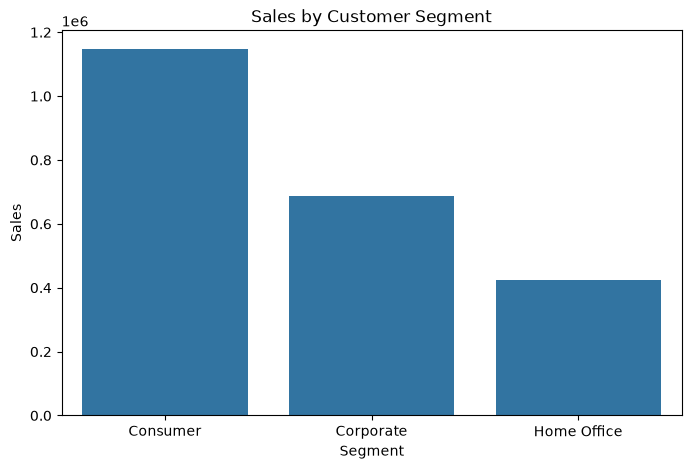

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(data=segment_sales,x='Segment',y='Sales')

plt.title('Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.show()

### Shipping analysis

In [31]:
shipping_analysis=(df.groupby('Ship Mode').agg(Sales=('Sales','sum'),Orders=('Order ID','nunique'),Avg_Shipping_Days=('Shipping_Days','mean')).sort_values('Sales',ascending=False))
shipping_analysis

,Sales,Orders,Avg_Shipping_Days
Ship Mode,,,
Standard Class,1.340831e+06,2945,5.008363
Second Class,4.499142e+05,944,3.249211
First Class,3.455723e+05,772,2.179214
Same Day,1.252190e+05,261,0.044610


### Sales share

In [32]:
category_sales['Sales_Share']=(category_sales['Sales']/total_sales*100)
category_sales

,Category,Sales,Sales_Share
0,Technology,827455.8730,36.588212
1,Furniture,728658.5757,32.219621
2,Office Supplies,705422.3340,31.192167


In [33]:
region_sales['Sales_Share']=(region_sales['Sales']/total_sales*100)
region_sales

,Region,Sales,Sales_Share
0,West,710219.6845,31.404295
1,East,669518.7260,29.604591
2,Central,492646.9132,21.783723
3,South,389151.4590,17.207390


## Initial Findings

1. Total sales are approximately $2.26 million across the dataset.
2. Sales declined slightly in 2016 but increased strongly in 2017 and 2018.
3. Q4 is the strongest quarter, with November and December showing particularly high sales.
4. The West region generates the highest total sales, while the South generates the lowest.
5. Technology is the highest-performing product category.
6. Phones and Chairs are the leading sub-categories by sales.
7. Consumer customers contribute the largest share of sales.
8. Standard Class is the most commonly used shipping mode.
9. A small number of high-value products contribute substantially to total sales.